# PRGA structural stagnation — reproducible simulations

This notebook reproduces the simulations for the **Power-Relaxed Greedy Algorithm (PRGA)** in the *standard* formulation used in the approximation-theory literature.

We generate two unit vectors $x_1,x_2\in\mathbb R^n$ with prescribed coherence
$$\langle x_1,x_2\rangle=\mu\in[0,1),$$
define a realizable target
$$y=(1-b)x_1 + b x_2,$$
and run PRGA with step sizes $\lambda_m=m^{-\alpha}$.

We produce:
1. **Stagnation vs coherence**: $\min_m \|r_m\|_2$ as a function of $\mu$, together with the theoretical lower bound from Theorem 1 (for $\alpha>1$).
2. **Effect of $\alpha$**: for a fixed coherence $\mu$, we plot the residual floor across different $\alpha$'s.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

def approx_P_alpha(alpha: float, K: int = 200_000) -> float:
    """Stable approximation of P_alpha = prod_{k=2}^∞ (1 - 1/k^alpha), valid for alpha>1.
    Uses log-summation to avoid numerical underflow.
    """
    if alpha <= 1.0:
        raise ValueError("P_alpha is strictly positive only for alpha>1.")
    k = np.arange(2, K + 1, dtype=np.float64)
    log_terms = np.log1p(-1.0 / (k ** alpha))  # log(1 - 1/k^alpha)
    return float(np.exp(np.sum(log_terms)))


### Constructing two unit vectors with prescribed coherence $\mu$

We sample a random unit vector $x_1$, then sample a random direction $u$ orthogonal to $x_1$,
and set
$$x_2=\mu\,x_1+\sqrt{1-\mu^2}\,u.$$
This ensures $\|x_2\|_2=1$ and $\langle x_1,x_2\rangle=\mu$.


In [3]:

def make_pair_with_coherence(n: int, mu: float, rng: np.random.Generator):
    """Return unit vectors x1,x2 in R^n with <x1,x2>=mu.

    Construction: x2 = mu x1 + sqrt(1-mu^2) u, where u is a unit vector orthogonal to x1.
    """
    if not (0.0 <= mu < 1.0):
        raise ValueError("mu must be in [0,1).")

    x1 = rng.standard_normal(n)
    x1 /= np.linalg.norm(x1)

    u = rng.standard_normal(n)
    u -= (u @ x1) * x1
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return make_pair_with_coherence(n, mu, rng)
    u /= u_norm

    x2 = mu * x1 + np.sqrt(1.0 - mu**2) * u
    x2 /= np.linalg.norm(x2)  # numerical safety
    return x1, x2


## PRGA (standard formulation)

Given a residual $r_{m-1}$, we select an atom maximizing $\langle r_{m-1}, g\rangle$ over the **symmetric** dictionary
$\mathcal D=\{\pm x_1,\pm x_2\}$.
Equivalently, we choose the index with largest absolute correlation and fix the sign:
$$g_m=\operatorname{sign}(\langle r_{m-1},x_i\rangle)\,x_i.$$

**Initialization (standard):**
$$f_0=0,\quad r_0=y,\quad
g_1=\arg\max_{g\in\mathcal D}\langle r_0,g\rangle,\quad
f_1=\langle r_0,g_1\rangle\,g_1,\quad r_1=y-f_1.$$

**Recursion (for $m\ge 2$):**
$$f_m=(1-\lambda_m)f_{m-1}+\lambda_m g_m,\qquad r_m=y-f_m.$$


In [4]:

def prga_two_atoms_standard(x1, x2, y, alpha: float, M: int):
    """PRGA in the standard approximation-theory form.

    - g_m is the signed unit atom maximizing <r_{m-1}, g> over {±x1,±x2}
    - f_1 = <r_0, g_1> g_1
    - for m>=2: f_m = (1-lam_m) f_{m-1} + lam_m g_m, lam_m=m^{-alpha}

    Returns residual norms for m=0..M.
    """
    f = np.zeros_like(y)
    r = y.copy()
    errs = [float(np.linalg.norm(r))]

    # m = 1 (standard)
    c1, c2 = float(r @ x1), float(r @ x2)
    if abs(c1) >= abs(c2):
        g1 = np.sign(c1) * x1
        a1 = abs(c1)  # <r0, g1>
    else:
        g1 = np.sign(c2) * x2
        a1 = abs(c2)
    f = a1 * g1
    r = y - f
    errs.append(float(np.linalg.norm(r)))

    # m >= 2
    for m in range(2, M + 1):
        lam = m ** (-alpha)

        c1, c2 = float(r @ x1), float(r @ x2)
        if abs(c1) >= abs(c2):
            g = np.sign(c1) * x1
        else:
            g = np.sign(c2) * x2

        f = (1.0 - lam) * f + lam * g
        r = y - f
        errs.append(float(np.linalg.norm(r)))

    return np.array(errs)


## Experiment 1 — Stagnation vs coherence (with theory lower bound)

For each $\mu\in[0,0.95]$ we generate $(x_1,x_2)$, form $y=(1-b)x_1+bx_2$ and run PRGA.
We plot:
- empirical $\min_{1\le m\le M}\|r_m\|_2$
- theoretical lower bound (Theorem 1) for $\alpha>1$:
$$b(1-\mu)\sqrt{\frac{1+\mu}{2}}\,P_\alpha.$$


In [5]:

def sweep_mu(
    n=200,
    b=0.25,
    alphas=(1.1, 1.5),
    M=800,
    mu_grid=None,
    seed=0,
    P_K=200_000
):
    rng = np.random.default_rng(seed)
    if mu_grid is None:
        mu_grid = np.linspace(0.0, 0.95, 20)

    P = {a: approx_P_alpha(a, K=P_K) for a in alphas}

    results = {a: {"mu": [], "min_err": [], "theory_lb": []} for a in alphas}

    for mu in mu_grid:
        x1, x2 = make_pair_with_coherence(n, float(mu), rng)
        y = (1.0 - b) * x1 + b * x2

        for a in alphas:
            errs = prga_two_atoms_standard(x1, x2, y, alpha=float(a), M=M)
            min_err = float(np.min(errs[1:]))  # ignore m=0
            lb = float(b * (1.0 - mu) * np.sqrt((1.0 + mu) / 2.0) * P[a])

            results[a]["mu"].append(float(mu))
            results[a]["min_err"].append(min_err)
            results[a]["theory_lb"].append(lb)

    return results, P


def plot_sweep_mu(results, title=None):
    plt.figure(figsize=(8, 6))
    for a, d in results.items():
        mu = np.array(d["mu"])
        val = np.array(d["min_err"])
        lb = np.array(d["theory_lb"])

        plt.plot(mu, val, marker="o", label=f"empirical min, alpha={a}")
        plt.plot(mu, lb, linestyle="--", linewidth=2, label=f"theory LB, alpha={a}")

    plt.yscale("log")
    plt.xlabel("coherence μ")
    plt.ylabel(r"$\min_{1<= m<= M}\|r_m\|_2$")
    if title:
        plt.title(title)
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.savefig("stagnation_vs_mu.png", dpi=300, bbox_inches="tight")
    plt.show()


Approximate P_alpha values:
alpha=1.1: P_alpha ≈ 0.00095595852061429
alpha=1.5: P_alpha ≈ 0.1767271295846129


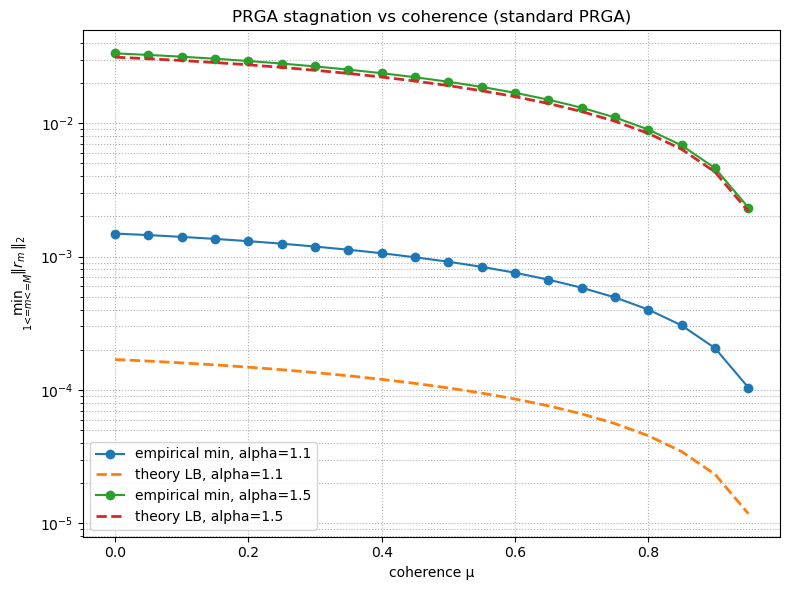

In [6]:

# Run Experiment 1
n = 200
b = 0.25
alphas = (1.1, 1.5)
M = 800
mu_grid = np.linspace(0.0, 0.95, 20)

results_mu, P = sweep_mu(n=n, b=b, alphas=alphas, M=M, mu_grid=mu_grid, seed=0)

print("Approximate P_alpha values:")
for a in P:
    print(f"alpha={a}: P_alpha ≈ {P[a]}")
    
plot_sweep_mu(results_mu, title="PRGA stagnation vs coherence (standard PRGA)")


## Experiment 2 — Effect of $\alpha$

We fix a coherence value $\mu$ and compare the stagnation indicator
$$\min_{1\le m\le M}\|r_m\|_2$$
as a function of $\alpha$.  
For $\alpha>1$, we also overlay the Theorem 1 lower bound.


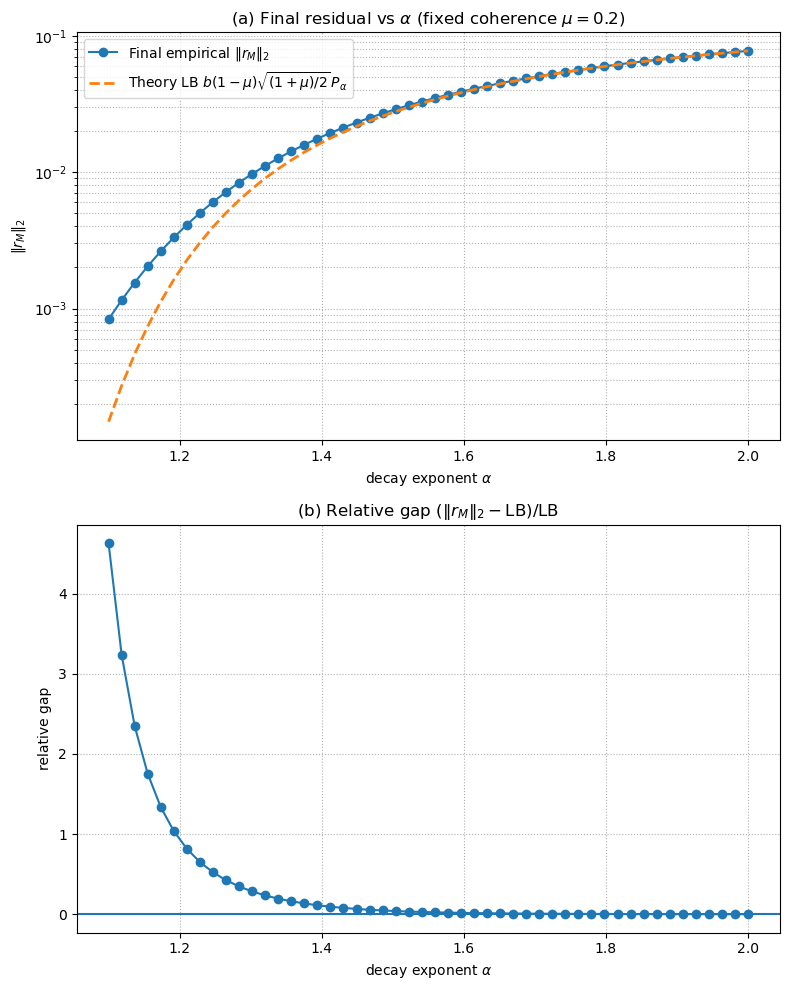

In [7]:
def sweep_alpha_fixed_mu_final(
    n=200,
    b=0.25,
    mu=0.2,
    alpha_grid=None,
    M=1200,
    seed=1,
    P_K=200_000
):
    rng = np.random.default_rng(seed)
    if alpha_grid is None:
        alpha_grid = np.linspace(1.1, 2.0, 60)

    x1, x2 = make_pair_with_coherence(n, float(mu), rng)
    y = (1.0 - b) * x1 + b * x2

    finals = []
    lbs = []

    for a in alpha_grid:
        a = float(a)

        errs = prga_two_atoms_standard(x1, x2, y, alpha=a, M=M)
        finals.append(float(errs[-1]))  # ||r_M||_2

        P_a = approx_P_alpha(a, K=P_K)
        lb = b * (1.0 - mu) * np.sqrt((1.0 + mu) / 2.0) * P_a
        lbs.append(float(lb))

    return np.array(alpha_grid), np.array(finals), np.array(lbs)


def plot_two_panel(alpha_grid, finals, lbs, mu):
    finals = np.array(finals)
    lbs = np.array(lbs)
    gap = finals - lbs
    gap_rel = gap / np.maximum(lbs, 1e-300)

    plt.figure(figsize=(8,10))

    # Panel (a): original
    plt.subplot(2,1,1)
    plt.plot(alpha_grid, finals, marker="o", label=r"Final empirical $\|r_M\|_2$")
    plt.plot(alpha_grid, lbs, linestyle="--", linewidth=2,
             label=r"Theory LB $b(1-\mu)\sqrt{(1+\mu)/2}\,P_\alpha$")
    plt.yscale("log")
    plt.xlabel(r"decay exponent $\alpha$")
    plt.ylabel(r"$\|r_M\|_2$")
    plt.title(rf"(a) Final residual vs $\alpha$ (fixed coherence $\mu={mu}$)")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()

    # Panel (b): relative gap
    plt.subplot(2,1,2)
    plt.plot(alpha_grid, gap_rel, marker="o")
    plt.axhline(0.0)
    plt.xlabel(r"decay exponent $\alpha$")
    plt.ylabel(r"relative gap")
    plt.title(r"(b) Relative gap $(\|r_M\|_2-\mathrm{LB})/\mathrm{LB}$")
    plt.grid(True, which="both", linestyle=":")
    plt.tight_layout()
    plt.savefig("stagnation_vs_alpha.png",dpi=300, bbox_inches="tight")
    plt.show()

# Run 
mu_fixed = 0.2
alpha_grid = np.linspace(1.1, 2.0, 50)   

a_grid, finals, lbs = sweep_alpha_fixed_mu_final(
    n=200, b=0.25, mu=mu_fixed,
    alpha_grid=alpha_grid, M=2000, seed=1, P_K=200_000  
)

plot_two_panel(a_grid, finals, lbs, mu_fixed)